# Intermediate-line experiments — win rate

Seven runs, two charts, one metric.

- **pooled** — one model trained on every pre-game snapshot at once, with
  `TIME_TO_MATCH_MIN` as a feature, so it can bet at any hour before tip.
- **control** — trained at one horizon only: 12 hours for both targets, plus
  the new 8-hour `line_error` control. Each serves exactly one bet time.
- **no decay** — pooled and 12-hour `line_error` repeats with recency weighting
  disabled.

Both targets: `line_error` (total minus the line) and `total_points` (the total).

Everything is re-scored from raw predictions at one common bet threshold, because
each run freezes its own into `betting_metrics.json` and the saved headline
numbers would otherwise be different measurements sitting in the same column.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from training_pipeline.reporting import discovery, rescore, theme
from training_pipeline.reporting import snapshot_charts as snap

theme.apply_theme()
pd.set_option("display.width", 200)

SOURCES = [
    "artifacts/experiments/intermediate_pooled_line_error_20260814_212934",
    "artifacts/experiments/intermediate_pooled_total_points_20260815_015408",
    "artifacts/experiments/intermediate_t720_control_line_error_20260815_025733",
    "artifacts/experiments/intermediate_t720_control_total_points_20260815_041410",
    "artifacts/experiments/intermediate_pooled_line_error_no_time_decay_20260817_011050",
    "artifacts/experiments/intermediate_t720_control_line_error_no_time_decay_20260817_021440",
    "artifacts/experiments/intermediate_t480_control_line_error_20260817_100940",
]
RESCORE_EDGE_THRESHOLD = 0.1
RESCORE_EV_THRESHOLD = 0.0

runs = theme.prepare_runs(discovery.load_runs(SOURCES, project_root=PROJECT_ROOT))
runs = rescore.apply_rescored(
    runs,
    rescore.rescore_runs(
        runs, edge_threshold=RESCORE_EDGE_THRESHOLD, ev_threshold=RESCORE_EV_THRESHOLD
    ),
)
metrics = snap.load_snapshot_metrics(runs)
print(f"{len(runs)} runs, re-scored at {RESCORE_EDGE_THRESHOLD} points.")

7 runs, re-scored at 0.1 points.


## 1. All bet times together

One CV and one holdout win rate per experiment. For a pooled run this pools all
six snapshots — fine as a point estimate; it is only the *interval* that repeated
games would invalidate, and no interval is drawn here.

The grey rule is break-even at −110 (**52.38%**). Below it a strategy loses money
however good the win rate looks in isolation.

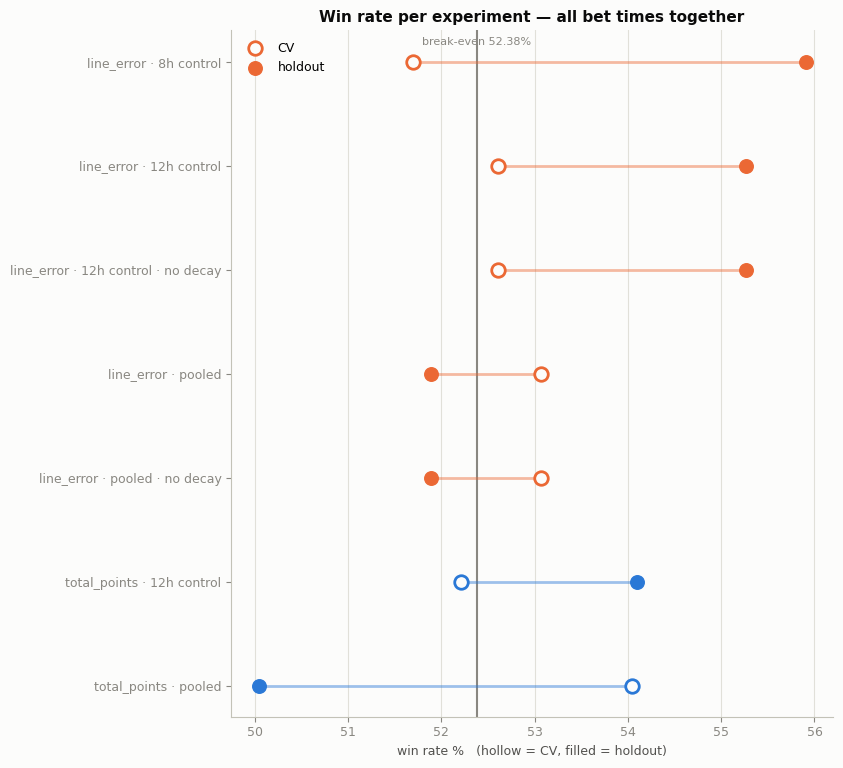

,experiment,label,strategy,variant,source,win_rate_pct
0,intermediate_t720_control_line_error_20260815_...,line_error · 12h control,line_error_regressor,control,cv,52.61
1,intermediate_t720_control_line_error_20260815_...,line_error · 12h control,line_error_regressor,control,holdout,55.26
2,intermediate_t720_control_line_error_no_time_d...,line_error · 12h control · no decay,line_error_regressor,control,cv,52.61
3,intermediate_t720_control_line_error_no_time_d...,line_error · 12h control · no decay,line_error_regressor,control,holdout,55.26
4,intermediate_t480_control_line_error_20260817_...,line_error · 8h control,line_error_regressor,control,cv,51.70
5,intermediate_t480_control_line_error_20260817_...,line_error · 8h control,line_error_regressor,control,holdout,55.91
6,intermediate_pooled_line_error_20260814_212934,line_error · pooled,line_error_regressor,pooled,cv,53.07
7,intermediate_pooled_line_error_20260814_212934,line_error · pooled,line_error_regressor,pooled,holdout,51.89
8,intermediate_pooled_line_error_no_time_decay_2...,line_error · pooled · no decay,line_error_regressor,pooled,cv,53.07
9,intermediate_pooled_line_error_no_time_decay_2...,line_error · pooled · no decay,line_error_regressor,pooled,holdout,51.89


In [2]:
overall = snap.win_rate_overall(runs, metrics)
snap.plot_win_rate_overall(overall)
plt.tight_layout()
plt.show()

overall.assign(win_rate_pct=(overall["win_rate"] * 100).round(2)).drop(columns="win_rate")

## 2. Split by bet time

Same metric against how long before tip-off the bet is placed. The pooled runs
have all six horizons; each control is a single point at the one horizon it was
trained on.

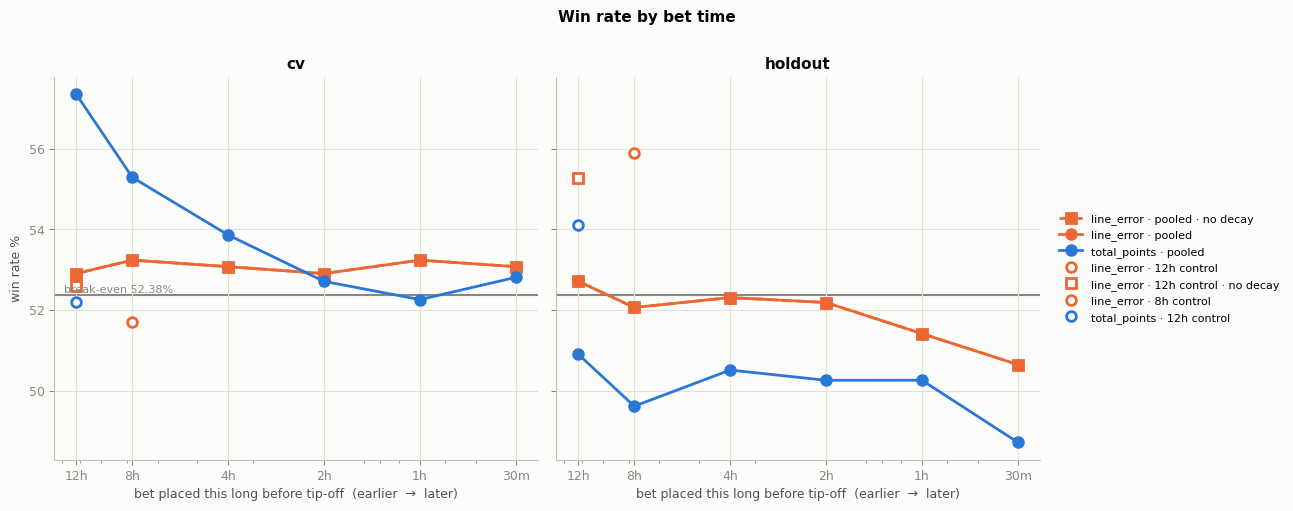

In [3]:
snap.plot_win_rate_split(metrics, runs)
plt.show()

In [4]:
by_time = snap.with_control_points(metrics, runs)
table = by_time.pivot_table(
    index=["prediction_strategy", "run_name", "snapshot"],
    columns="source", values="win_rate",
)
(table * 100).round(2)

source                                                                                 cv  holdout
prediction_strategy    run_name                                           snapshot                
line_error_regressor   intermediate_pooled_line_error_20260814_212934     30.0      53.07    50.65
                                                                          60.0      53.24    51.41
                                                                          120.0     52.90    52.19
                                                                          240.0     53.07    52.31
                                                                          480.0     53.24    52.06
                                                                          720.0     52.90    52.71
                       intermediate_pooled_line_error_no_time_decay_20... 30.0      53.07    50.65
                                                                          60.0      53.24    51.41
                                                                          120.0     52.90    52.19
                                                                          240.0     53.07    52.31
                                                                          480.0     53.24    52.06
                                                                          720.0     52.90    52.71
                       intermediate_t480_control_line_error_20260817_1... 480.0     51.70    55.91
                       intermediate_t720_control_line_error_20260815_0... 720.0     52.61    55.26
                       intermediate_t720_control_line_error_no_time_de... 720.0     52.61    55.26
total_points_regressor intermediate_pooled_total_points_20260815_015408   30.0      52.81    48.72
                                                                          60.0      52.26    50.26
                                                                          120.0     52.71    50.26
                                                                          240.0     53.86    50.51
                                                                          480.0     55.29    49.61
                                                                          720.0     57.35    50.90
                       intermediate_t720_control_total_points_20260815... 720.0     52.21    54.10

## Reading it

Four things to hold on to while looking at the charts.

**The noise floor.** Re-running one of these configs with only the seed changed
moves holdout ROI by 3.2 to 11.9 points, which is far wider than any gap on
screen. Every difference here is inside that, so the charts show *shape*, not a
ranking.

**The no-decay repeats overlap exactly.** Their predictions and metrics are
byte-identical to the original pooled and 12-hour `line_error` runs. The original
configs resolved to a null decay rate, so this did not produce an effective
time-decay A/B test; overlapping markers are the expected result.

**The 8-hour comparison is inconclusive.** The pooled `line_error` run is ahead
in CV (53.24% vs 51.70%) but behind the 8-hour control in the holdout (52.06%
vs 55.91%). The direction reversal is consistent with the noise warning above,
not evidence for either design.

**Break-even is the bar, not 50%.** At −110 a strategy needs 52.38% to break even,
and a Wilson interval on ~400 bets is roughly ±5 points — wide enough that none of
these per-time win rates separates from break-even in the holdout.